# Part 3: LSTM

**Owner:** Parfait Christian Henry UHIRIWE

This notebook is my part of the group project on vaccine sentiment, and it builds the second recurrent model in the comparison: an embedding layer, an LSTM layer and a single linear output that predicts where a tweet sits on the sentiment scale from -1 (anti-vaccine) to +1 (pro-vaccine). The question for this part is whether the memory cell of an LSTM, which can keep or forget information as it reads a tweet, helps more than the plain recurrent state of the Simple RNN. The LSTM uses the shared split, the text cleaning Fred chose in notebook 01 and the same vectorizer settings as the Simple RNN, so both models read exactly the same token input. Each model was tuned separately, however, and the final LSTM and Simple RNN also differ in embedding size, dropout and batch size, so a difference between them reflects each model's tuning as well as its recurrent cell.

| Output | Path |
|---|---|
| Validation predictions | `results/lstm_validation_predictions.csv` |
| Experiment log | `results/experiments/lstm_experiments.csv` |
| Figures | `results/figures/lstm_*.png` |
| Final model | `models/lstm.keras` (+ `models/lstm_vectorizer.json`) |

## 1. Setup

In [ ]:
# Setup: works on Google Colab and locally.
import subprocess
import sys
from pathlib import Path

REPO = "vaccine-sentiment-sequential-models"
if "google.colab" in sys.modules:
    ROOT = Path("/content") / REPO
    if not ROOT.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/Adossi-design/{REPO}.git", str(ROOT)], check=True)
    else:  # get teammates' latest pushes (e.g. the split files)
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(ROOT / "requirements.txt")], check=True)
else:
    ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "common.py").exists())
sys.path.insert(0, str(ROOT))

from src import common

common.print_environment()
common.set_seed()

Python 3.13.15
numpy 2.1.3
pandas 2.2.3
scikit-learn 1.6.1
tensorflow 2.20.0
keras 3.13.2
GPU Tesla T4


The data is not stored in the repository, so the next cell makes sure `data/Train.csv` is available. On Colab it asks for the file to be uploaded, and in both cases it checks the file against the official version so that every model is trained on identical data.

In [ ]:
common.fetch_train_csv()

PosixPath('/content/vaccine-sentiment-sequential-models/data/Train.csv')

In [ ]:
import json

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras import layers

from src.preprocess import prepare_series

RESULTS_DIR = Path(common.RESULTS_DIR)
FIGURES_DIR = Path(common.FIGURES_DIR)
MODELS_DIR = Path(common.MODELS_DIR)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OWNER = "Parfait Christian Henry UHIRIWE"

## 2. Preparing the Data

The training and validation rows come from the shared split through `common.load_train_validation()`, which also checks that the two ID files do not overlap and that every row has a valid label. The text then goes through `prepare_series()`, which is the cleaning Fred decided on in notebook 01, so the LSTM sees tweets prepared in exactly the same way as every other model.

In [ ]:
train_df, val_df = common.load_train_validation()
train_text = np.asarray(prepare_series(train_df["safe_text"]), dtype=str)
val_text = np.asarray(prepare_series(val_df["safe_text"]), dtype=str)
y_train = train_df["label"].to_numpy(dtype="float32")
y_val = val_df["label"].to_numpy(dtype="float32")

print(f"Training tweets: {len(train_df)}, validation tweets: {len(val_df)}")
print(train_df["label"].value_counts().sort_index())

Training tweets: 8001, validation tweets: 1999
label
-1.0     832
 0.0    3926
 1.0    3243
Name: count, dtype: int64


The Simple RNN notebook already chose the vocabulary size and sequence length from the training split and saved them in `models/simple_rnn_vectorizer.json`. I reuse those settings rather than choosing new ones, because giving both models the same token input removes the input as a possible cause of any difference between them. The cell below also recomputes the length statistics on the cleaned training text, so the reused sequence length can be checked against the data rather than taken on trust.

In [ ]:
with open(MODELS_DIR / "simple_rnn_vectorizer.json") as f:
    rnn_vectorizer_settings = json.load(f)

MAX_TOKENS = rnn_vectorizer_settings["max_tokens"]
MAX_LEN = rnn_vectorizer_settings["max_len"]

token_counts = np.array([len(text.split()) for text in train_text])
print(f"Reused settings: max_tokens={MAX_TOKENS}, max_len={MAX_LEN}")
print(f"Median length: {np.median(token_counts):.0f} tokens, 99th percentile: {np.percentile(token_counts, 99):.0f} tokens")
print(f"Training tweets longer than max_len: {(token_counts > MAX_LEN).mean():.2%}")

Reused settings: max_tokens=5666, max_len=28
Median length: 17 tokens, 99th percentile: 28 tokens
Training tweets longer than max_len: 0.74%


The vectorizer uses `standardize=None` and splits on whitespace because `prepare_series()` has already cleaned the text, and the default Keras standardiser would remove the hashtags, punctuation and emojis that notebook 01 decided to keep. It is adapted on the training tweets only, so nothing about the validation vocabulary reaches the model.

In [ ]:
vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=None,
    split="whitespace",
    output_sequence_length=MAX_LEN,
)
vectorizer.adapt(train_text)

X_train = keras.ops.convert_to_numpy(vectorizer(train_text))
X_val = keras.ops.convert_to_numpy(vectorizer(val_text))
print(f"Vocabulary size: {vectorizer.vocabulary_size()}, input shapes: {X_train.shape}, {X_val.shape}")

Vocabulary size: 5666, input shapes: (8001, 28), (1999, 28)


## 3. Building the Model

The network reads the token IDs through an embedding layer, passes them through one LSTM layer and ends with a single linear unit, because the target is a continuous score scored with RMSE. The embedding uses `mask_zero=True` so that the padding added to short tweets does not flow through the memory cell as if it were text. Dropout is applied through the LSTM's own `dropout` argument, which keeps the fast cuDNN kernel on a GPU, whereas `recurrent_dropout` would switch to a much slower implementation. The bidirectional option is kept in the same function because one experiment tests it, and it still uses the same LSTM cell.

In [ ]:
def build_lstm(embedding_dim, units, dropout, learning_rate, bidirectional=False):
    """Build an embedding, LSTM and linear output network that predicts a tweet sentiment score."""
    inputs = keras.Input(shape=(MAX_LEN,), dtype="int64")
    x = layers.Embedding(vectorizer.vocabulary_size(), embedding_dim, mask_zero=True)(inputs)
    lstm_layer = layers.LSTM(units, dropout=dropout)
    x = layers.Bidirectional(lstm_layer)(x) if bidirectional else lstm_layer(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


build_lstm(embedding_dim=64, units=64, dropout=0.0, learning_rate=1e-3).summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 28, 64)    │    362,624 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 28)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         65 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 395,713 (1.51 MB)

 Trainable params: 395,713 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training and Logging Runs

Every run goes through `train_lstm()`, so the seed, early stopping and the RMSE calculation stay identical between experiments. Early stopping watches the validation loss and restores the best weights, which stops training once the model starts fitting noise in the training set. The validation RMSE is computed with `common.rmse`, as the group conventions require, and the predictions are not clipped to [-1, 1] because the group left that decision to notebook 05 so it can be applied to all five models together.

Logging is a separate step on purpose. `log_run()` refuses to write a run until its observation has been written, so every row in the experiment log contains a note that was made after looking at the actual result.

In [ ]:
BASE_CONFIG = {
    "embedding_dim": 64,
    "units": 64,
    "dropout": 0.0,
    "learning_rate": 1e-3,
    "batch_size": 32,
    "epochs": 30,
    "patience": 3,
    "bidirectional": False,
    "agreement_weights": False,
}
runs = {}


def train_lstm(run_id, config, seed=42):
    """Train one LSTM configuration on the training split and return its validation results."""
    common.set_seed(seed)
    model = build_lstm(config["embedding_dim"], config["units"], config["dropout"], config["learning_rate"], config["bidirectional"])
    sample_weight = train_df["agreement"].to_numpy(dtype="float32") if config["agreement_weights"] else None
    early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=config["patience"], restore_best_weights=True)

    history = model.fit(
        X_train,
        y_train,
        sample_weight=sample_weight,
        validation_data=(X_val, y_val),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        callbacks=[early_stopping],
        verbose=0,
    )
    y_pred = model.predict(X_val, verbose=0).ravel()

    result = {
        "run_id": run_id,
        "seed": seed,
        "config": dict(config),
        "model": model,
        "history": history.history,
        "y_pred": y_pred,
        "val_rmse": common.rmse(val_df["label"], y_pred),
        "best_epoch": int(np.argmin(history.history["val_loss"])) + 1,
    }
    runs[run_id] = result
    print(f"{run_id} (seed {seed}): validation RMSE {result['val_rmse']:.4f}, best epoch {result['best_epoch']} of {len(history.history['loss'])}")
    return result


def log_run(result, change_from_previous, observation):
    """Record one finished run in the LSTM experiment log once its observation has been written."""
    if not observation:
        raise ValueError(f"Write the observation for {result['run_id']} after reading its result, then run this cell again.")
    config = result["config"]
    common.log_experiment(
        run_id=result["run_id"],
        owner=OWNER,
        model="lstm",
        approach="Embedding -> Bidirectional LSTM -> Dense(1)" if config["bidirectional"] else "Embedding -> LSTM -> Dense(1)",
        input_representation=f"token IDs from TextVectorization (max_tokens={MAX_TOKENS}, max_len={MAX_LEN}, same settings as the Simple RNN)",
        preprocessing="agreed notebook 01 text preparation (prepare_series)",
        hyperparameters={**config, "seed": result["seed"], "best_epoch": result["best_epoch"]},
        change_from_previous=change_from_previous,
        val_rmse=result["val_rmse"],
        observation=observation,
    )


def plot_learning_curve(result, title, save_name=None):
    """Plot the training and validation RMSE of one run across epochs."""
    plt.figure(figsize=(7, 4))
    plt.plot(result["history"]["rmse"], label="training RMSE")
    plt.plot(result["history"]["val_rmse"], label="validation RMSE")
    plt.axvline(result["best_epoch"] - 1, color="grey", linestyle="--", label="restored epoch")
    plt.xlabel("epoch")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_name:
        plt.savefig(FIGURES_DIR / save_name, dpi=150)
    plt.show()

## 5. Experiments

### 5.1 Starting configuration

The first run uses moderate settings with no dropout, so that it gives a clear reference point and shows whether the LSTM overfits before any regularisation is added.

lstm-01 (seed 42): validation RMSE 0.5780, best epoch 1 of 4


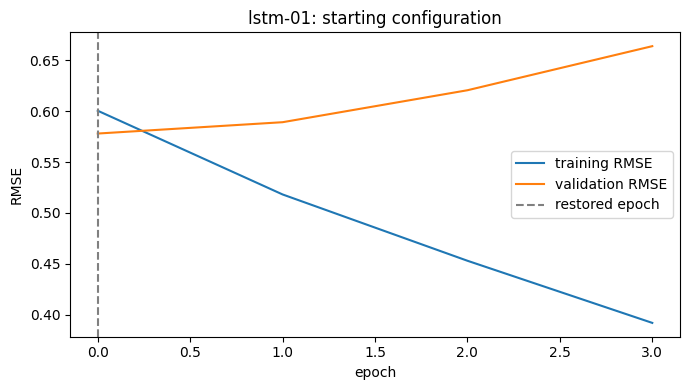

In [ ]:
lstm_01 = train_lstm("lstm-01", BASE_CONFIG)
plot_learning_curve(lstm_01, "lstm-01: starting configuration")

In [ ]:
log_run(
    lstm_01,
    change_from_previous="first run: reference LSTM on the same token input as the Simple RNN",
    observation="Validation RMSE was lowest after the first epoch (0.5780) and rose in each of the next three epochs while training RMSE kept falling from about 0.60 to 0.39, so the LSTM starts memorising the training tweets almost immediately. The result is already better than the constant-mean baseline (0.6459), but it comes from a single seed and cannot be compared with the Simple RNN (0.5855) until the seed noise is known. The early overfitting motivates testing dropout, a smaller embedding and a lower learning rate next.",
    )

### 5.2 How much do results move between seeds?

A recurrent network can give a different RMSE from a different random start even when nothing else changes. Before judging any change, the starting configuration is trained with two more seeds, and the spread of the three results gives the size of a difference that could appear by chance. A later change only counts as an improvement if it beats the starting configuration by more than this spread.

This rule differs slightly from the one in notebooks 02 and 04, which compare each change with the seed-42 starting run and require a gain larger than √2 times the seed standard deviation (about 0.0055 here). The conclusion in section 5.3 is the same under either rule, because the largest gain over the seed-42 run is 0.0032 (lstm-05). Judging changes over several seeds rather than a single run follows Reimers and Gurevych (2017).

In [ ]:
noise_runs = [lstm_01] + [train_lstm(f"lstm-01-seed{seed}", BASE_CONFIG, seed=seed) for seed in (43, 44)]
noise_rmse = np.array([run["val_rmse"] for run in noise_runs])
baseline_mean = float(noise_rmse.mean())
seed_noise = float(noise_rmse.std(ddof=1))
print(f"Starting configuration over three seeds: mean RMSE {baseline_mean:.4f}, standard deviation {seed_noise:.4f}")

lstm-01-seed43 (seed 43): validation RMSE 0.5704, best epoch 1 of 4
lstm-01-seed44 (seed 44): validation RMSE 0.5759, best epoch 1 of 4
Starting configuration over three seeds: mean RMSE 0.5748, standard deviation 0.0039


In [ ]:
noise_observations = {
    "lstm-01-seed43": "With seed 43 the same configuration reached 0.5704, again at the first epoch, which is 0.0076 lower than seed 42 without any change to the model. Differences of several thousandths can therefore come from the random start alone, so single runs cannot be compared on that scale.",
    "lstm-01-seed44": "Seed 44 gave 0.5759 and also peaked after the first epoch, so the early overfitting is consistent across all three seeds. The three seeds give a mean of 0.5748 with a standard deviation of 0.0039, which is the margin a later change must beat to count as an improvement.",
}
for run in noise_runs[1:]:
    log_run(run, "seed check: same configuration as lstm-01 with a different seed", noise_observations[run["run_id"]])

### 5.3 One change at a time

Each run below changes a single setting from the starting configuration, so that any difference in RMSE can be linked to that one setting. The reason for each change is written next to it.

The last run weights each training tweet by its annotator agreement. The agreement column is still not a model input, since the model never sees it and it is not needed at prediction time. It only reduces how much the low-agreement tweets pull on the training loss, which tests whether noisy labels are limiting the LSTM.

In [ ]:
one_change_runs = {
    "lstm-02": ({"dropout": 0.3}, "adds input dropout of 0.3 to test whether the starting LSTM overfits the small training set"),
    "lstm-03": ({"units": 128}, "doubles the LSTM units to 128 to test whether a larger memory cell helps"),
    "lstm-04": ({"embedding_dim": 32}, "halves the embedding to 32, the size the Simple RNN finally used, to test whether a smaller embedding is enough"),
    "lstm-05": ({"bidirectional": True}, "reads each tweet in both directions to test whether context from later words, such as a late negation, helps"),
    "lstm-06": ({"agreement_weights": True}, "weights training tweets by annotator agreement to test whether uncertain labels limit the model"),
    "lstm-07": ({"learning_rate": 3e-4}, "lowers the learning rate to 3e-4 because lstm-01 reached its best validation RMSE after one epoch, so a slower rate may show the curve in more detail and reach a better point"),
}

change_results = {run_id: train_lstm(run_id, {**BASE_CONFIG, **change}) for run_id, (change, _) in one_change_runs.items()}

comparison = pd.DataFrame(
    [{"run_id": run_id, "val_rmse": result["val_rmse"], "best_epoch": result["best_epoch"]} for run_id, result in change_results.items()]
)
comparison["improvement_over_mean"] = baseline_mean - comparison["val_rmse"]
comparison["beats_seed_noise"] = comparison["improvement_over_mean"] > seed_noise
print(f"Starting mean {baseline_mean:.4f}, seed noise {seed_noise:.4f}")
print(comparison[["run_id", "val_rmse", "improvement_over_mean", "beats_seed_noise", "best_epoch"]].round(4).to_string(index=False))

lstm-02 (seed 42): validation RMSE 0.5782, best epoch 1 of 4
lstm-03 (seed 42): validation RMSE 0.5796, best epoch 1 of 4
lstm-04 (seed 42): validation RMSE 0.5795, best epoch 1 of 4
lstm-05 (seed 42): validation RMSE 0.5748, best epoch 1 of 4
lstm-06 (seed 42): validation RMSE 0.5750, best epoch 1 of 4
lstm-07 (seed 42): validation RMSE 0.5750, best epoch 2 of 5
Starting mean 0.5748, seed noise 0.0039
 run_id  val_rmse  improvement_over_mean  beats_seed_noise  best_epoch
lstm-02    0.5782                -0.0034             False           1
lstm-03    0.5796                -0.0049             False           1
lstm-04    0.5795                -0.0047             False           1
lstm-05    0.5748                -0.0000             False           1
lstm-06    0.5750                -0.0002             False           1
lstm-07    0.5750                -0.0002             False           2


In [ ]:
change_observations = {
    "lstm-02": "Input dropout of 0.3 gave 0.5782, almost identical to the same-seed starting run (0.5780) and within the seed noise, and the model still reached its best validation RMSE after the first epoch. Dropout at this level therefore did not delay or reduce the early overfitting.",
    "lstm-03": "Doubling the LSTM units to 128 gave 0.5796, within the seed noise of the same-seed starting run (0.5780), and the best epoch was still the first. A larger memory cell added parameters without a measurable benefit, which is consistent with tweets that are mostly short (median 17 tokens).",
    "lstm-04": "Halving the embedding to 32 dimensions gave 0.5795, within the seed noise of the same-seed starting run (0.5780), even though it removes about half of the model's parameters. The embedding size does not appear to limit the LSTM at this data size.",
    "lstm-05": "Reading each tweet in both directions gave 0.5748, 0.0032 lower than the same-seed starting run but still within the seed noise, while doubling the recurrent parameters. The expected benefit of context from later words, such as a late negation, did not show up as a measurable gain on this validation set.",
    "lstm-06": "Weighting training tweets by annotator agreement gave 0.5750, within the seed noise, so reducing the influence of uncertain labels did not change the result measurably. This suggests that low-agreement tweets are not the main source of the remaining error, which the error analysis can check directly.",
    "lstm-07": "Lowering the learning rate to 3e-4 moved the best epoch from the first to the second but gave the same RMSE (0.5750), within the seed noise. The early peak in lstm-01 does not appear to come from a learning rate that was too fast, since a slower rate reaches the same level and then overfits in the same way.",
}
for run_id, result in change_results.items():
    log_run(result, one_change_runs[run_id][1], change_observations[run_id])

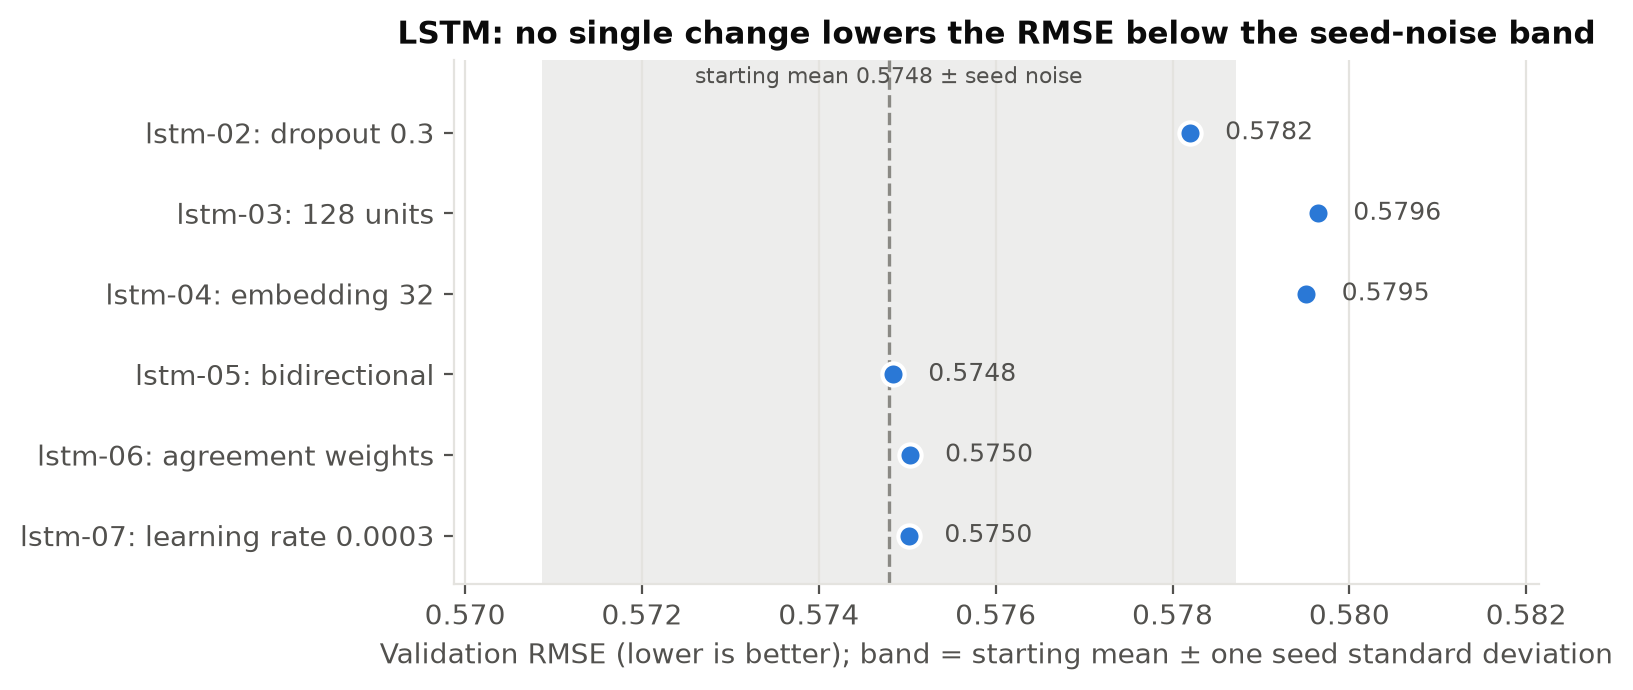

In [ ]:
# Same figure style as notebook 05: dots on a recessive grid, text in ink colours.
INK, INK_2, GRID, GRAY, BLUE = "#0b0b0b", "#52514e", "#e4e3df", "#8a8984", "#2a78d6"
SETTINGS = {"lstm-02": "dropout 0.3", "lstm-03": "128 units", "lstm-04": "embedding 32",
            "lstm-05": "bidirectional", "lstm-06": "agreement weights", "lstm-07": "learning rate 0.0003"}
with plt.rc_context({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "savefig.dpi": 200, "savefig.bbox": "tight",
}):
    order = comparison.iloc[::-1]  # first change at the top
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.axvspan(baseline_mean - seed_noise, baseline_mean + seed_noise, color=GRAY, alpha=0.15, linewidth=0)
    ax.axvline(baseline_mean, color=GRAY, linestyle="--", linewidth=1.2)
    ax.scatter(order["val_rmse"], range(len(order)), color=BLUE, s=64, zorder=3, edgecolors="white", linewidths=1.5)
    for i, value in enumerate(order["val_rmse"]):
        ax.text(value + 0.0004, i, f"{value:.4f}", va="center", color=INK_2, fontsize=9)
    ax.text(baseline_mean, len(order) - 0.45, f"starting mean {baseline_mean:.4f} ± seed noise",
            ha="center", va="bottom", color=INK_2, fontsize=8)
    ax.set_yticks(range(len(order)), [f"{run_id}: {SETTINGS[run_id]}" for run_id in order["run_id"]])
    ax.set_ylim(-0.6, len(order) - 0.1)
    ax.set_xlim(baseline_mean - seed_noise - 0.001, order["val_rmse"].max() + 0.0025)
    ax.grid(axis="y", visible=False)
    ax.set(xlabel="Validation RMSE (lower is better); band = starting mean ± one seed standard deviation",
           title="LSTM: no single change lowers the RMSE below the seed-noise band")
    fig.savefig(FIGURES_DIR / "lstm_experiments.png")
    plt.show()

### 5.4 Final configuration

The final configuration keeps only the changes that beat the seed noise in the table above. If no change clearly helps, the starting configuration is kept, since adding settings that make no measurable difference would only make the model harder to explain. The chosen configuration is then trained on three fresh seeds that were not used for any decision, which checks that the result was not a lucky run.

In [ ]:
# Add only the changes that beat the seed noise, for example {"dropout": 0.3}.
final_changes = {}
FINAL_CONFIG = {**BASE_CONFIG, **final_changes}

final_run = train_lstm("lstm-final", FINAL_CONFIG, seed=42)
fresh_runs = [train_lstm(f"lstm-final-seed{seed}", FINAL_CONFIG, seed=seed) for seed in (7, 123, 2026)]
fresh_rmse = np.array([run["val_rmse"] for run in fresh_runs])
print(f"Final configuration on fresh seeds: mean RMSE {fresh_rmse.mean():.4f}, standard deviation {fresh_rmse.std(ddof=1):.4f}")

lstm-final (seed 42): validation RMSE 0.5780, best epoch 1 of 4
lstm-final-seed7 (seed 7): validation RMSE 0.5796, best epoch 1 of 4
lstm-final-seed123 (seed 123): validation RMSE 0.5878, best epoch 2 of 5
lstm-final-seed2026 (seed 2026): validation RMSE 0.5735, best epoch 1 of 4
Final configuration on fresh seeds: mean RMSE 0.5803, standard deviation 0.0072


In [ ]:
all_seed_rmse = np.array([run["val_rmse"] for run in noise_runs + fresh_runs])
print(f"Starting configuration over all six seeds: mean RMSE {all_seed_rmse.mean():.4f}, standard deviation {all_seed_rmse.std(ddof=1):.4f}, range {all_seed_rmse.min():.4f} to {all_seed_rmse.max():.4f}")

Starting configuration over all six seeds: mean RMSE 0.5776, standard deviation 0.0060, range 0.5704 to 0.5878


In [ ]:
final_observations = {
    "lstm-final": "Retraining the starting configuration with seed 42 reproduced 0.5780 and the same best epoch as lstm-01, which confirms that runs with the same seed are repeatable in this environment. This run is kept as the official LSTM result because seed 42 is the group's shared seed.",
    "lstm-final-seed7": "Seed 7 gave 0.5796 and peaked after the first epoch, which is close to the earlier seed check and shows the same early overfitting.",
    "lstm-final-seed123": "Seed 123 gave 0.5878, the highest RMSE of any run of this configuration, and peaked at the second epoch instead of the first. This one seed widens the spread noticeably, which shows that the three-seed noise estimate of 0.0039 understated how much results can vary.",
    "lstm-final-seed2026": "Seed 2026 gave 0.5735, within the range of the earlier seed check. Across the three fresh seeds the mean is 0.5803 with a standard deviation of 0.0072, so the training pattern is stable but the exact RMSE can move by close to 0.01 from one seed to the next.",
}
final_change = f"final configuration: starting configuration plus {final_changes}" if final_changes else "final configuration: starting configuration, since no change beat the seed noise"
for run in [final_run] + fresh_runs:
    log_run(run, final_change, final_observations[run["run_id"]])

The seed 42 run of the final configuration is the official LSTM result, which matches the seed used across the group. Its learning curve, predictions, model and vectorizer settings are saved below.

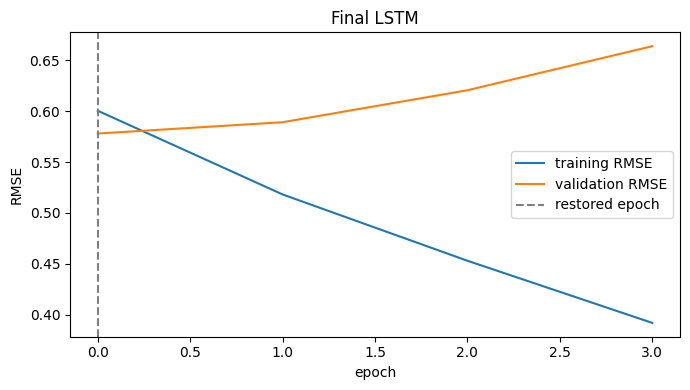

Saved results/lstm_validation_predictions.csv (validation RMSE 0.5780)


In [ ]:
plot_learning_curve(final_run, "Final LSTM", save_name="lstm_learning_curve.png")

y_pred = final_run["y_pred"]
common.save_predictions("lstm", val_df, y_pred)
final_run["model"].save(MODELS_DIR / "lstm.keras")

with open(MODELS_DIR / "lstm_vectorizer.json", "w") as f:
    json.dump(
        {
            "standardize": "none (prepare_series already cleans the text)",
            "split": "whitespace",
            "max_tokens": MAX_TOKENS,
            "max_len": MAX_LEN,
            "adapted_on": "shared training split (splits/train_ids.csv)",
            "preprocessing": "prepare_series() from src/preprocess.py: the shared cleaning chosen in notebook 01 from the EDA",
        },
        f,
        indent=2,
    )

## 6. Error Analysis

RMSE compresses every error into one number, so this section looks at where the errors come from. The first cell splits the RMSE by true label, because an overall score can hide a model that does well on the common classes and badly on a rare one.

In [ ]:
print(f"Mean training label: {y_train.mean():.4f}")

Mean training label: 0.3013


 label  tweets   rmse  mean_prediction
  -1.0     206 1.3148           0.2767
   0.0     982 0.3334           0.2331
   1.0     811 0.4998           0.5808


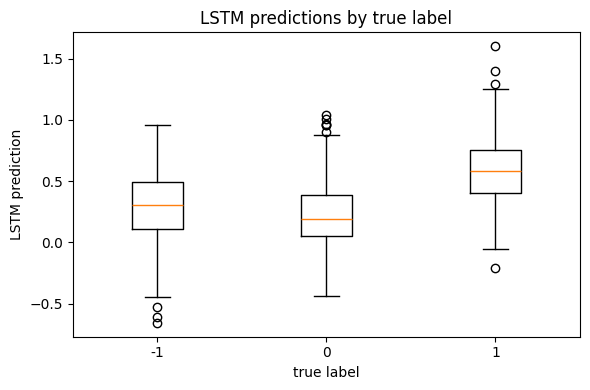

In [ ]:
analysis = val_df[["tweet_id", "safe_text", "label", "agreement"]].copy()
analysis["lstm_pred"] = y_pred
analysis["abs_error"] = (analysis["lstm_pred"] - analysis["label"]).abs()

label_rows = [
    {"label": label, "tweets": len(group), "rmse": common.rmse(group["label"], group["lstm_pred"]), "mean_prediction": group["lstm_pred"].mean()}
    for label, group in analysis.groupby("label")
]
print(pd.DataFrame(label_rows).round(4).to_string(index=False))

plt.figure(figsize=(6, 4))
plt.boxplot([analysis.loc[analysis["label"] == label, "lstm_pred"] for label in (-1, 0, 1)])
plt.xticks([1, 2, 3], ["-1", "0", "1"])
plt.xlabel("true label")
plt.ylabel("LSTM prediction")
plt.title("LSTM predictions by true label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_predictions_by_label.png", dpi=150)
plt.show()

The error is concentrated almost entirely in the negative class. Neutral and positive tweets have an RMSE of 0.3334 and 0.4998, but the 206 anti-vaccine tweets have an RMSE of 1.3148, and their mean prediction of 0.2767 is on the positive side of the scale and close to the mean training label printed above. For most anti-vaccine tweets the LSTM therefore stays near its average prediction instead of moving towards -1. The box plot shows the same pattern: the middle half of the predictions for every class falls between about 0.1 and 0.75, so the model uses only a narrow part of the scale. Negative tweets make up only about 10% of the training split, and a regression trained with mean squared error tends to stay near the average for a rare class, which is a likely explanation for this pattern, although this notebook does not test it directly.

Rounding the predictions to the nearest label turns them into classes, and the cross-table below shows which mistakes the model makes. Confusing a neutral tweet with a neighbouring class is a much smaller problem than calling an anti-vaccine tweet pro-vaccine. The rounding is only used to read the errors and does not replace RMSE.

In [ ]:
analysis["rounded_pred"] = analysis["lstm_pred"].round().clip(-1, 1).astype(int)
print(pd.crosstab(analysis["label"], analysis["rounded_pred"], rownames=["true"], colnames=["rounded prediction"]))

rounded prediction  -1    0    1
true                            
-1.0                 3  153   50
 0.0                 0  840  142
 1.0                 0  319  492


The cross-table shows how serious this is. Of the 206 anti-vaccine tweets, only 3 are rounded to -1, while 153 become neutral and 50 become pro-vaccine, and no other tweet is rounded to -1 at all. The neutral and positive classes are mostly separated correctly, and most of their mistakes go to the neighbouring class (142 neutral tweets rounded to positive and 319 positive tweets rounded to neutral). The LSTM therefore behaves almost like a two-class model that separates neutral from pro-vaccine tweets, and the 50 anti-vaccine tweets predicted as pro-vaccine are the most serious errors because they reverse the stance of the tweet.

The next cell checks whether the largest errors are concentrated on tweets where the annotators disagreed. If they are, part of the remaining error may come from uncertain labels rather than from the model.

In [ ]:
largest = analysis.nlargest(15, "abs_error")
print(f"Mean agreement, all validation tweets: {analysis['agreement'].mean():.3f}")
print(f"Mean agreement, 15 largest errors: {largest['agreement'].mean():.3f}")
print(f"Full-agreement tweets among the 15 largest errors: {(largest['agreement'] == 1).sum()}")
print(analysis.groupby("agreement")["abs_error"].agg(["count", "mean"]).round(4))

Mean agreement, all validation tweets: 0.854
Mean agreement, 15 largest errors: 0.644
Full-agreement tweets among the 15 largest errors: 4
           count    mean
agreement               
0.333333      47  1.3758
0.666667     779  0.5032
1.000000    1173  0.3498


Annotator agreement explains part of the error but not all of it. The 15 largest errors have a mean agreement of 0.644, well below the 0.854 of the whole validation set, and the mean absolute error rises steadily as agreement falls, from 0.3498 on full-agreement tweets to 0.5032 at two-thirds agreement and 1.3758 on the 47 tweets where only one of the three annotators chose the recorded label. For those tweets the label itself is uncertain, so part of the measured error may come from the label rather than the model. However, 4 of the 15 largest errors have full agreement, so label noise cannot be the whole explanation. This also fits the result of lstm-06: weighting by agreement changes how the model is trained, but it cannot change the uncertain labels in the validation set that the model is scored against.

The cell below lists the 15 tweets with the largest errors by ID only, because the group does not publish tweet text from the dataset. I read each of these tweets in `Train.csv` before describing them below, and where the text gives no clear reason for an error, it is better to say so than to force it into a category.

In [ ]:
print(largest[["tweet_id", "label", "lstm_pred", "abs_error", "agreement"]].round(3).to_string(index=False))

All 15 largest errors are anti-vaccine tweets predicted between 0.71 and 0.96, so the model reads each of them as clearly pro-vaccine. Reading the text suggests three groups. The first group states an anti-vaccine view by negating a phrase that would otherwise sound pro-vaccine, such as a short reply telling parents not to vaccinate their children (5KDOWBMS), a tweet warning parents not to let schools push them into vaccinating (QK5Y1ZWX) and a parent saying their unvaccinated children do not get sick like other children (AXIE5AEC). These tweets have high agreement and direct wording, so they are the clearest failures of the model: the words that carry the stance are present, but the LSTM does not seem to use the negation to reverse the meaning of what follows. The second group uses sarcasm or quotes another view, such as a tweet that quotes a pro-vaccine appeal and then questions it with an autism claim (DVMK1WEI), or one that compares immunisation with giving children chickenpox (AP8D8KXB), where the literal words point the opposite way from the intended stance. The third group contains tweets whose label is itself debatable. Some criticise a politician for supporting parental choice (4F3XQO7P, 1KAVNQ0L) or report anti-vaccine behaviour in a headline (A3W81QVQ), which could reasonably be read as pro-vaccine or neutral, and all three have an agreement of 0.333 or 0.667. For this group the prediction may be closer to the author's stance than the label is, so these examples say more about the difficulty of the annotation than about the LSTM.

## 7. Comparison with the Simple RNN

Both models use the same split, cleaning and token input, so the input is not a source of difference between them. Their tuned settings do differ, however, so the comparison below mixes the effect of the recurrent cell with each model's tuning. The Simple RNN's largest errors were negative tweets predicted as positive, several of which contained negation. A memory cell should in principle carry a negation forward to the words it affects, so the cell below measures the error on tweets with and without negation words for both models, rather than assuming the LSTM handles them better.

In [ ]:
rnn_predictions = pd.read_csv(RESULTS_DIR / "rnn_validation_predictions.csv")[["tweet_id", "predicted_label"]]
both = analysis.merge(rnn_predictions.rename(columns={"predicted_label": "rnn_pred"}), on="tweet_id", how="inner")
assert len(both) == len(analysis), "The Simple RNN predictions do not cover the same validation tweets."

print(f"Validation RMSE, Simple RNN: {common.rmse(both['label'], both['rnn_pred']):.4f}")
print(f"Validation RMSE, LSTM: {common.rmse(both['label'], both['lstm_pred']):.4f}")

both["has_negation"] = both["safe_text"].str.lower().str.contains(r"\b(?:not|no|never|nor|cannot)\b|n't", regex=True)
rows = []
for (label, has_negation), group in both.groupby(["label", "has_negation"]):
    rows.append({"label": label, "has_negation": has_negation, "tweets": len(group), "rnn_rmse": common.rmse(group["label"], group["rnn_pred"]), "lstm_rmse": common.rmse(group["label"], group["lstm_pred"])})
print(pd.DataFrame(rows).round(4).to_string(index=False))

both["rnn_abs_error"] = (both["rnn_pred"] - both["label"]).abs()
rnn_top = set(both.nlargest(50, "rnn_abs_error")["tweet_id"])
lstm_top = set(both.nlargest(50, "abs_error")["tweet_id"])
print(f"Tweets in both models' 50 largest errors: {len(rnn_top & lstm_top)}")

Validation RMSE, Simple RNN: 0.5855
Validation RMSE, LSTM: 0.5780
 label  has_negation  tweets  rnn_rmse  lstm_rmse
  -1.0         False     147    1.2735     1.2769
  -1.0          True      59    1.4390     1.4048
   0.0         False     811    0.2906     0.3136
   0.0          True     171    0.3691     0.4146
   1.0         False     534    0.5701     0.5285
   1.0          True     277    0.4627     0.4391
Tweets in both models' 50 largest errors: 35


The LSTM reached a validation RMSE of 0.5780 on the same 1,999 tweets where the Simple RNN reached 0.5855. The gap of 0.0075 is larger than the LSTM's seed standard deviation (0.0060) but falls inside the range of its six seeds (0.5704 to 0.5878 in section 5.4), and the two models also differ in their tuned settings, so this comparison does not show that the LSTM is reliably better or that its memory cell is the reason for the gap. The table by label shows where the small difference comes from. The LSTM has lower error on pro-vaccine tweets, both with and without negation, but higher error on neutral tweets, and on anti-vaccine tweets without negation the two models are almost identical (1.2735 and 1.2769).

The negation rows test the idea that motivated this model. Anti-vaccine tweets that contain a negation word are the hardest group for both models, and the LSTM only lowers their RMSE from 1.4390 to 1.4048, which leaves them far above every other group. Negation is also common in pro-vaccine tweets (277 of 811), so a negation word on its own does not signal an anti-vaccine view, and the model has to learn what the negation applies to. Anti-vaccine tweets make up only 832 of the 8,001 training tweets, and only some of those contain negation, so there are few examples to learn this from. In our experiments the LSTM did not close the gap on negated anti-vaccine tweets, so its ability to carry information across a tweet does not appear to be what limits it on this data. Finally, 35 of the 50 largest errors are shared by the two models, which suggests that much of the remaining error comes from the data and the task rather than from either model's design. The negation check uses a simple word list that misses negation expressed in other ways, and its pattern also misses negations written with a curly apostrophe, so it should be read as a rough split. Notebook 05 uses a corrected pattern and compares all five approaches on the same tweets.

## 8. Summary

The LSTM reached a validation RMSE of 0.5780 with the group's seed and 0.5776 on average across six seeds, compared with 0.5855 for the Simple RNN on the same tweets. None of the six changes tested in section 5.3 improved on the starting configuration by more than the seed noise, and every run reached its best validation RMSE within the first two epochs, so the model fits the training tweets quickly and further training only adds overfitting. The main weakness is the anti-vaccine class: the LSTM rounds only 3 of the 206 anti-vaccine tweets to -1, and its error on those tweets is nearly the same as the Simple RNN's. The memory cell was expected to help most with negation, but negated anti-vaccine tweets remain the hardest group for both models, and most of the hardest tweets are shared between them. Because the two models were tuned separately, this comparison cannot isolate the effect of the memory cell. What it does show is that both models fail on the same anti-vaccine tweets, which suggests that in our experiments the small number of anti-vaccine training tweets and the reliability of their labels limit these models more than the choice of recurrent cell does. Realistic next steps would be to give the anti-vaccine class more weight during training and to test pretrained embeddings or a pretrained language model that already represents how negation changes meaning. Notebook 05 compares all five approaches on the same tweets.



## 9. Notes and Sources

Literature used for the decisions in this notebook:

- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735-1780. The LSTM architecture and its memory cell.
- Bengio, Y., Simard, P., & Frasconi, P. (1994). Learning long-term dependencies with gradient descent is difficult. *IEEE Transactions on Neural Networks, 5*(2), 157-166. Why a plain RNN struggles to carry information across a sequence, which motivates comparing it with the LSTM.
- Gers, F. A., Schmidhuber, J., & Cummins, F. (2000). Learning to forget: Continual prediction with LSTM. *Neural Computation, 12*(10), 2451-2471. The forget gate used in modern LSTM layers.
- Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural networks. *IEEE Transactions on Signal Processing, 45*(11), 2673-2681. The basis for experiment lstm-05.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*, 1929-1958. The basis for experiment lstm-02.
- Müller, M. M., & Salathé, M. (2019). Crowdbreaks: Tracking health trends using public social media data and crowdsourcing. *Frontiers in Public Health, 7*, 81. The source of the tweets and the three-annotator labels.
- Reimers, N., & Gurevych, I. (2017). Reporting score distributions makes a difference: Performance study of LSTM-networks for sequence tagging. In *Proceedings of the 2017 Conference on Empirical Methods in Natural Language Processing* (pp. 338-348). The reason for judging changes over several seeds.
- Zindi. (2020). *To vaccinate or not to vaccinate: It's not a question* [Data set]. https://zindi.africa/competitions/to-vaccinate-or-not-to-vaccinate. The challenge the tweets and labels come from.